# 📓 Notebook 7 — Model Comparison
### AirSense AI — Intelligent Urban Air Quality Forecasting & Decision Support System

**Purpose of this notebook**

Notebook 6 trained and scored 4 models (Persistence, SARIMA, LSTM, BiLSTM —
Prophet was skipped due to a Windows/cmdstan environment issue). This
notebook:

1. Loads Notebook 6's saved results
2. Builds the final comparison table
3. Goes beyond the raw metrics with visual comparisons (error distribution,
   performance during a real spike) — a model can have a deceptively good
   RMSE while still missing the timing of pollution spikes that matter most
4. Selects a winner **programmatically** (lowest RMSE), not by assumption
5. Saves the winning model as `best_model.keras` (or `.pkl` for a
   non-Keras winner) for Notebook 8 to deploy

⚠️ **Reminder from Notebook 6:** SARIMA's score reflects a single blind
30-day-ahead forecast, which structurally disadvantages it compared to
Persistence/LSTM/BiLSTM (which all get fresh real PM2.5 history at every
test hour). Notebook 6's rolling 3-day re-forecast demo showed SARIMA
performs much better in a realistic daily-refit setup. Keep this context in
mind when interpreting SARIMA's row below — a low score here doesn't mean
SARIMA is unusable in production, only that it's weaker at unassisted
long-range extrapolation.

---


## 1. Imports & setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import joblib
import shutil

pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Libraries loaded.


## 2. Load Notebook 6's results and candidate models

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pc\Desktop\AirSenseAI")
MODELS_DIR = PROJECT_ROOT / "models"

checkpoint_path = MODELS_DIR / "notebook6_results.pkl"
print("Checkpoint file:", checkpoint_path, "| exists:", checkpoint_path.exists())

Checkpoint file: C:\Users\pc\Desktop\AirSenseAI\models\notebook6_results.pkl | exists: True


In [3]:
with open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

results_df = checkpoint['results_df']
predictions = checkpoint['predictions']
y_true = checkpoint['y_true']
test_time = pd.to_datetime(checkpoint['test_time'])

print("Models evaluated:", list(results_df.index))
results_df

Models evaluated: ['Persistence', 'SARIMA', 'LSTM', 'BiLSTM']


,MAE,RMSE,MAPE,R2
Model,,,,
Persistence,1.432,2.424,14.166,0.925
SARIMA,7.054,8.928,99.920,-0.015
LSTM,1.250,2.084,13.585,0.945
BiLSTM,1.390,2.158,15.370,0.941


**Note:** if you re-ran Notebook 6 with Prophet included (e.g. after
fixing the cmdstan issue on your machine), it will simply appear as an
additional row here automatically — nothing else in this notebook needs to
change.

## 3. Final comparison table

Sorted by RMSE (primary metric) — lower is better for MAE/RMSE/MAPE, higher
is better for R².

In [4]:
comparison_table = results_df.sort_values('RMSE').copy()
comparison_table.style.background_gradient(subset=['MAE', 'RMSE', 'MAPE'], cmap='Reds') \
                        .background_gradient(subset=['R2'], cmap='Greens')

,MAE,RMSE,MAPE,R2
Model,,,,
LSTM,1.250000,2.084000,13.585000,0.945000
BiLSTM,1.390000,2.158000,15.370000,0.941000
Persistence,1.432000,2.424000,14.166000,0.925000
SARIMA,7.054000,8.928000,99.920000,-0.015000


## 4. Visual comparison — bar chart across all metrics

A single table can hide how much models differ. This makes the gaps between
models immediately visible.

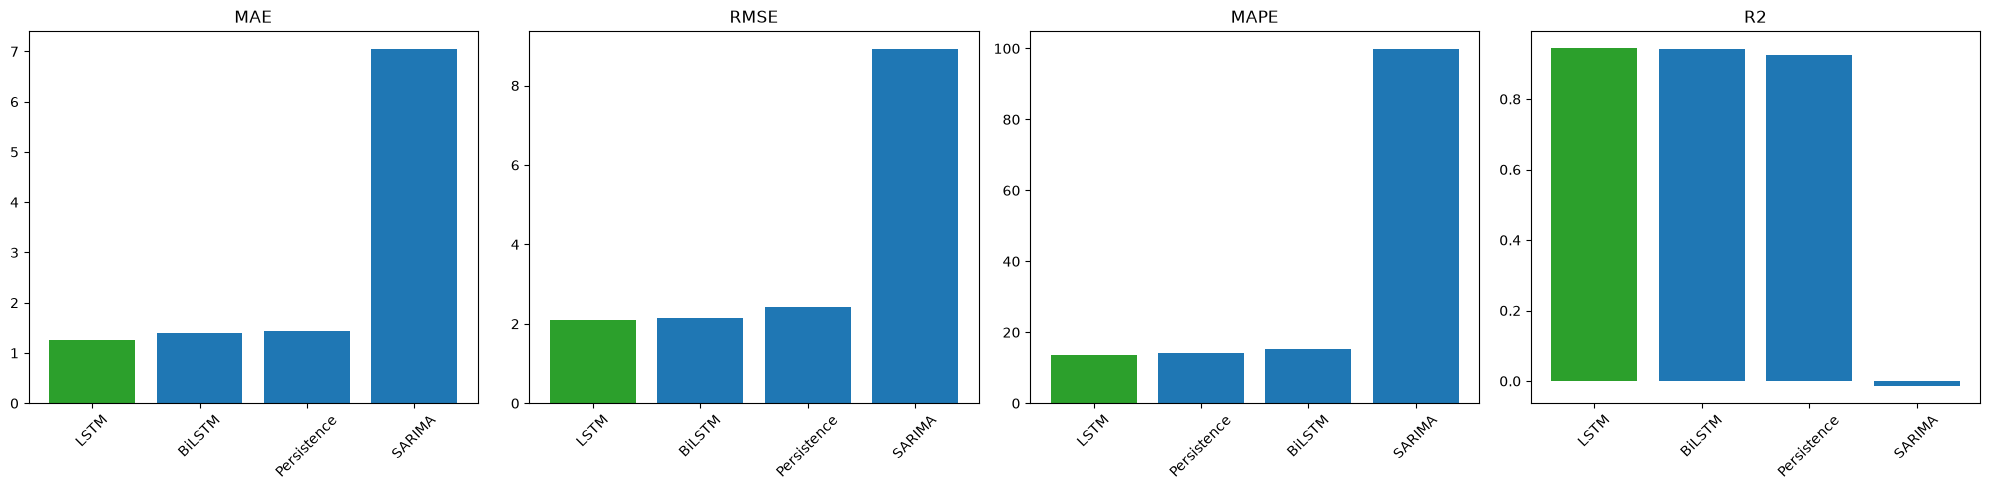

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']

for ax, metric in zip(axes, metrics):
    sorted_vals = comparison_table[metric].sort_values(ascending=(metric != 'R2'))
    colors = ['tab:green' if i == 0 else 'tab:blue' for i in range(len(sorted_vals))]
    ax.bar(sorted_vals.index, sorted_vals.values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note whether one model wins across all four metrics consistently, or whether
different metrics favor different models — the latter is common and means
the "winner" decision involves a genuine tradeoff, not just picking an
obvious best.

## 5. Residual analysis

Looking at *how* each model is wrong, not just *how much*. A tight, roughly
symmetric residual distribution centered at 0 indicates unbiased errors; a
skewed or wide distribution suggests systematic problems (e.g.
under-predicting spikes).

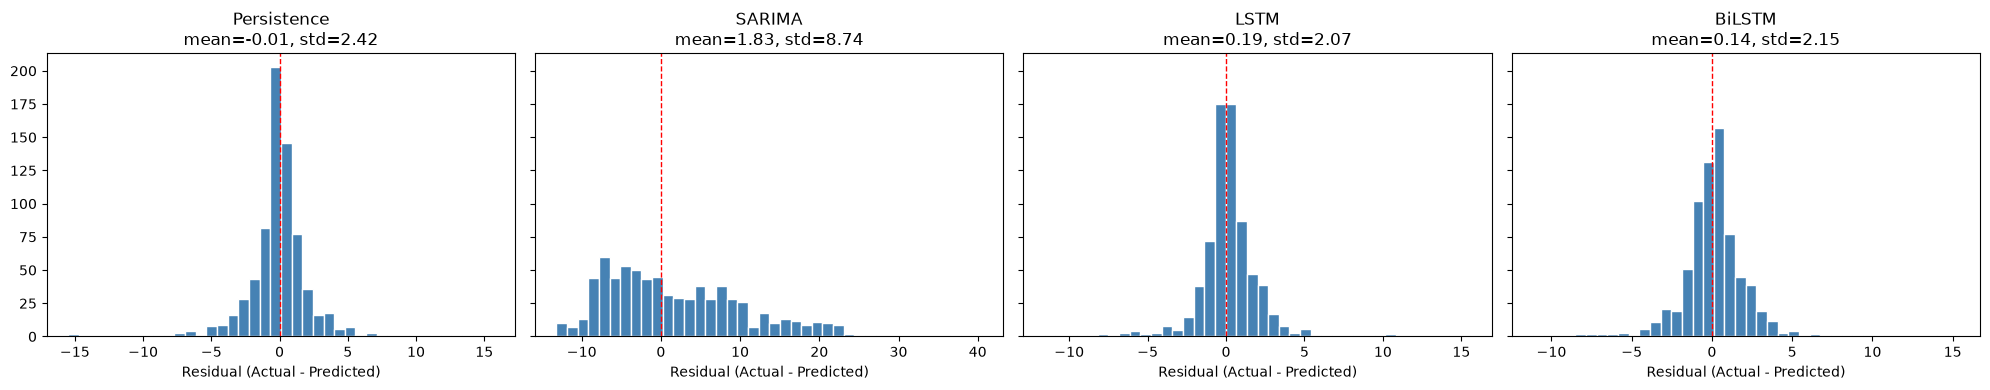

In [6]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4), sharey=True)
if len(predictions) == 1:
    axes = [axes]

for ax, (model_name, preds) in zip(axes, predictions.items()):
    residuals = y_true - preds
    ax.hist(residuals, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{model_name}\nmean={residuals.mean():.2f}, std={residuals.std():.2f}")
    ax.set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note which model's residuals are most tightly clustered around 0. A residual
mean far from 0 indicates the model is systematically over- or
under-predicting PM2.5, which matters for a public-health-facing dashboard
even if the average error (MAE) looks acceptable.

## 6. Performance during the largest real spike

Average error metrics can hide poor performance exactly when it matters
most — during a pollution spike, which is when accurate forecasts are most
valuable for public health alerts. We zoom into the actual worst spike in
the test period and see which model actually caught it.

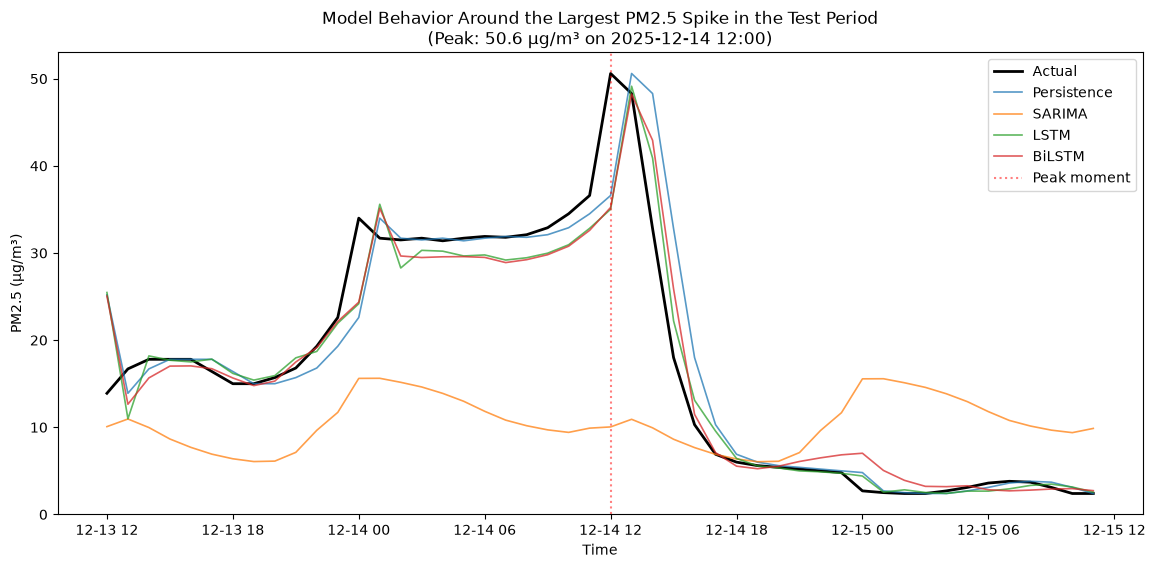

In [7]:
spike_idx = np.argmax(y_true)
window_start = max(0, spike_idx - 24)
window_end = min(len(y_true), spike_idx + 24)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_time[window_start:window_end], y_true[window_start:window_end],
        label='Actual', color='black', linewidth=2)

for model_name, preds in predictions.items():
    ax.plot(test_time[window_start:window_end], preds[window_start:window_end],
            label=model_name, alpha=0.75, linewidth=1.2)

ax.axvline(test_time[spike_idx], color='red', linestyle=':', alpha=0.5, label='Peak moment')
ax.set_xlabel("Time")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title(f"Model Behavior Around the Largest PM2.5 Spike in the Test Period\n"
             f"(Peak: {y_true[spike_idx]:.1f} μg/m³ on {test_time[spike_idx]:%Y-%m-%d %H:%M})")
ax.legend()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note which model's curve rises and falls closest to the actual black line
around the peak — even a model with a strong overall RMSE can flatten out
and miss the magnitude of a real spike, which is exactly the scenario an
air-quality alert system most needs to get right.

## 7. Select the winner

Winner is selected **programmatically** by lowest RMSE — this avoids
letting an assumption about "LSTM should win" or similar bias the decision.
Re-run this notebook after any change to Notebook 6 and the winner updates
automatically.

In [8]:
winner_name = comparison_table.index[0]
winner_row = comparison_table.loc[winner_name]

print(f"🏆 Winning model: {winner_name}")
print()
print(winner_row)

🏆 Winning model: LSTM

MAE      1.250
RMSE     2.084
MAPE    13.585
R2       0.945
Name: LSTM, dtype: float64


**A note on judgment, not just automation:** the metric-based winner
above is a strong starting point, but Sections 5 and 6 matter too. If the
top-by-RMSE model showed a systematically biased residual mean, or clearly
missed the real spike in Section 6, that's a legitimate reason to
override this automatic choice — document your reasoning here if you do.

## 8. Save the winning model as `best_model`

The save logic branches depending on which model type won, since each is
saved differently:
- **LSTM / BiLSTM** → copy the corresponding `.keras` file to
  `best_model.keras`
- **SARIMA** → save the fitted `statsmodels` results object with `pickle`
  as `best_model.pkl`
- **Persistence** → save a tiny wrapper class as `best_model.pkl`, since
  there's no trained object — just the rule "predict PM2.5(t-1)"

In [9]:
if winner_name in ("LSTM", "BiLSTM"):
    source_file = MODELS_DIR / f"candidate_{winner_name.lower()}.keras"
    dest_file = MODELS_DIR / "best_model.keras"
    shutil.copy(source_file, dest_file)
    print(f"Saved {dest_file} (copied from {source_file.name})")

elif winner_name == "SARIMA":
    dest_file = MODELS_DIR / "best_model.pkl"
    with open(dest_file, "wb") as f:
        pickle.dump(checkpoint['sarima_fit'], f)
    print(f"Saved {dest_file} (SARIMA fitted results object)")

elif winner_name == "Persistence":
    class PersistenceModel:
        """Trivial model: predicts PM2.5(t) = PM2.5(t-1).
        Defined here so it can be saved/reloaded; redefine this exact class
        in Notebook 8 / the dashboard before unpickling."""
        def predict(self, last_known_pm25):
            return last_known_pm25

    dest_file = MODELS_DIR / "best_model.pkl"
    with open(dest_file, "wb") as f:
        pickle.dump(PersistenceModel(), f)
    print(f"Saved {dest_file} (Persistence wrapper)")
    print("⚠️ Reminder: redefine the PersistenceModel class before unpickling elsewhere.")

else:
    print(f"⚠️ No save logic defined for '{winner_name}' — add a branch above if a new model type wins.")

Saved C:\Users\pc\Desktop\AirSenseAI\models\best_model.keras (copied from candidate_lstm.keras)


## 9. Save the comparison table

Kept as a checkpoint for Notebook 8 and for reference in the dashboard's
"Model Performance" tab.

In [10]:
comparison_table.to_csv(MODELS_DIR / "model_comparison.csv")
print("Saved:", MODELS_DIR / "model_comparison.csv")
comparison_table

Saved: C:\Users\pc\Desktop\AirSenseAI\models\model_comparison.csv


,MAE,RMSE,MAPE,R2
Model,,,,
LSTM,1.250,2.084,13.585,0.945
BiLSTM,1.390,2.158,15.370,0.941
Persistence,1.432,2.424,14.166,0.925
SARIMA,7.054,8.928,99.920,-0.015


## 10. Summary

- ✅ Loaded and consolidated Notebook 6's results into a single comparison
  table
- ✅ Visualized metric differences, residual distributions, and behavior
  during the largest real PM2.5 spike in the test period
- ✅ Selected a winner programmatically by RMSE, with room for documented
  judgment-based override
- ✅ Saved the winning model as `best_model.keras` or `best_model.pkl`
- ✅ Saved the full comparison table as `model_comparison.csv`

**Next step → Notebook 8 (Deployment Preparation):**
Export the best model, scaler, and feature list together in the exact form
the Streamlit dashboard needs to load and serve real-time PM2.5 forecasts.